# Dubai Real Estate Market Analysis (2020–2026)
### Exploratory Data Analysis, Price Forecasting, Market Analysis

data source : https://www.kaggle.com/datasets/sergionefedov/dubai-real-estate-sales-and-rentals-20202026/data

A comprehensive dataset of the Dubai real estate market covering three segments — secondary sales, off-plan (new construction), and rentals — across 84 communities and 52 zones. Spans January 2020 to April 2026, capturing the most consequential market events of the period: the COVID-era dip, the Expo 2020 anticipation rally, the post-2022 capital influx (notably from Russia and the CIS), the October 2022 Golden Visa expansion, and the post-rally cooling of 2024–2025.

The dataset combines real geographic anchors (community coordinates, Dubai Metro stations, CBUAE base rate timeline, DLD/Property Finder–anchored base prices per zone) with a hedonic pricing model that produces realistic listing-level data. Coordinates and metro stations are real; listing-level apartment characteristics are generated from the hedonic model.

All prices are in USD for international comparability. Area is provided in both sqft (Dubai standard) and m² (international standard).

### what do i want to do here?

I want to answer 1 question: What factors influence property prices in Dubai, and what are the future prospects?

### Setup & Data Overview

In [49]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# import warnings
# warnings.filterwarnings("ignore")

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

In [50]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sergionefedov/dubai-real-estate-sales-and-rentals-20202026")

print("Path to dataset files:", path)

import os

data_name = os.listdir(path)
data_name

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\sergionefedov\dubai-real-estate-sales-and-rentals-20202026\versions\2


['area_prices_monthly.csv',
 'metro_stations.csv',
 'off_plan.csv',
 'rentals.csv',
 'secondary_sales.csv']

In [51]:
area_prices = pd.read_csv(os.path.join(path, data_name[0]))
metro_prices = pd.read_csv(os.path.join(path, data_name[1]))
offplan = pd.read_csv(os.path.join(path, data_name[2]), parse_dates=['date_listed'])
rentals = pd.read_csv(os.path.join(path, data_name[3]), parse_dates=['date_listed'])
secondary = pd.read_csv(os.path.join(path, data_name[4]), parse_dates=['date_listed'])

In [52]:
from IPython.display import display

print("=== AREA PRICES ===")
display(area_prices.head(), area_prices.shape)

print("=== METRO PRICES ===")
display(metro_prices.head(), metro_prices.shape)

print("=== OFFPLAN ===")
display(offplan.head(), offplan.shape)

print("=== RENTALS ===")
display(rentals.head())

print("=== SECONDARY SALES ===")
display(secondary.head(), secondary.shape)

=== AREA PRICES ===


,year_month,community,zone,is_freehold,secondary_price_per_sqft_usd,secondary_price_per_m2_usd,offplan_price_per_sqft_usd,rental_price_per_sqft_annual_usd,n_listings_secondary,n_listings_offplan,n_listings_rental,cbuae_base_rate_pct,avg_mortgage_rate_pct
0,2020-01,Palm Jumeirah,Palm Jumeirah,True,662,7126,752.0,43,26,72,111,1.5,3.0
1,2020-02,Palm Jumeirah,Palm Jumeirah,True,666,7167,728.0,43,64,78,45,1.5,3.0
2,2020-03,Palm Jumeirah,Palm Jumeirah,True,703,7564,762.0,46,144,71,99,1.5,3.0
3,2020-04,Palm Jumeirah,Palm Jumeirah,True,651,7002,727.0,42,146,69,14,0.4,1.9
4,2020-05,Palm Jumeirah,Palm Jumeirah,True,637,6852,676.0,41,147,28,83,0.4,1.9


(6384, 13)

=== METRO PRICES ===


,station_name,line,lat,lon,year_opened,to_burj_khalifa_km
0,UAE Exchange,Red,24.9756,55.0700,2011,32.11
1,Energy,Red,24.9844,55.0866,2011,30.29
2,Ibn Battuta,Red,25.0445,55.1180,2011,23.16
3,Jebel Ali,Red,25.0050,55.1335,2011,25.65
4,Danube,Red,25.0185,55.1230,2011,25.04


...

=== RENTALS ===


,id,date_listed,community,zone,lat,lon,property_category,property_type,bedrooms,area_sqft,...,parking_spaces,metro_station,metro_line,metro_distance_min,to_burj_khalifa_km,contract_type,n_cheques,annual_rent_usd,rent_per_sqft_usd,rent_per_m2_usd
0,R000001,2024-12-20,Town Square,Nshama,25.02906,55.25610,apartment,1BR,1,748,...,1,Centrepoint,Red,373,18.79,yearly,6,13700,18,196
1,R000002,2021-07-06,Expo City,Dubai South,24.96152,55.15759,apartment,1BR,1,1011,...,2,Expo 2020,Red,7,28.73,yearly,6,12700,12,135
2,R000003,2023-05-10,Palm Jumeirah,Palm Jumeirah,25.10836,55.13304,apartment,1BR,1,825,...,2,Mashreq Bank,Red,44,17.32,yearly,1,59900,72,782
3,R000004,2021-12-30,Deira,Deira,25.28720,55.30205,apartment,1BR,1,755,...,1,Al Jafiliya,Red,62,10.39,yearly,1,9300,12,133
4,R000005,2023-12-08,The Views,The Greens,25.08438,55.18399,apartment,1BR,1,746,...,1,Dubai Internet City,Red,5,15.50,short_term,12,31300,41,451


=== SECONDARY SALES ===


,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,...,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,...,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,...,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,...,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,...,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,...,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


(50000, 29)

In [53]:
def segment_stats(df, price_col, name):
    print(f'\n=== {name} ===')
    print(f'  Date range : {df["date_listed"].min().date()} -> {df["date_listed"].max().date()}')
    print(f'  Communities: {df["community"].nunique()}')
    print(f'  Median {price_col}: {df[price_col].median():>15,.0f} USD')
    print(f'  Mean   {price_col}: {df[price_col].mean():>15,.0f} USD')

segment_stats(secondary, 'price_usd', 'Secondary Sales')
segment_stats(offplan,   'price_usd', 'Off-Plan')
segment_stats(rentals,   'annual_rent_usd', 'Rentals')


=== Secondary Sales ===
  Date range : 2020-01-01 -> 2026-04-29
  Communities: 84
  Median price_usd:         593,700 USD
  Mean   price_usd:       1,014,038 USD

=== Off-Plan ===
  Date range : 2021-01-01 -> 2026-04-29
  Communities: 71
  Median price_usd:       1,018,100 USD
  Mean   price_usd:       1,698,503 USD

=== Rentals ===
  Date range : 2021-01-01 -> 2026-04-29
  Communities: 84
  Median annual_rent_usd:          47,050 USD
  Mean   annual_rent_usd:          83,687 USD


## Chapter : 1. Dubai Real Estate Market Condition

In [54]:
zone_stats = secondary.groupby('zone').agg(
    mean_price_per_sqft = ('price_per_sqft_usd', 'mean'),
    n_listings = ('id', 'count')
).sort_values('mean_price_per_sqft', ascending=False).reset_index()

zone_stats.head(15)

,zone,mean_price_per_sqft,n_listings
0,Jumeirah Bay,2276.821849,595
1,DIFC,1066.754653,591
2,Jumeirah,935.467819,4801
3,Emirates Hills,910.772652,607
4,Downtown,898.110016,609
5,Palm Jumeirah,885.709507,568
6,World Islands,859.608997,578
7,Al Wasl,743.522689,595
8,Dubai Marina,629.029961,2303
9,Business Bay,585.380952,546


### 1.1 where is the zone with the most expensive prices?

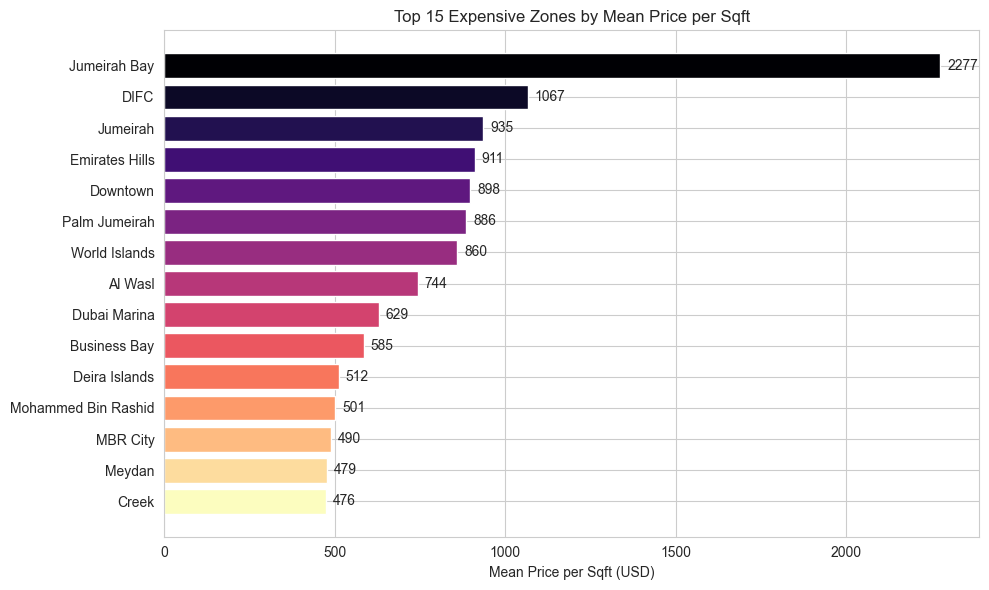

In [55]:
colors = plt.cm.magma(np.linspace(0, 1, len(zone_stats.head(15))))

top15 = zone_stats.head(15)

plt.figure(figsize=(10, 6))
barh =plt.barh(
    y=top15['zone'],                 
    width=top15['mean_price_per_sqft'],
    color=colors
)

plt.title('Top 15 Expensive Zones by Mean Price per Sqft')
plt.xlabel('Mean Price per Sqft (USD)')
plt.bar_label(barh, fmt='%.0f', padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

os.makedirs('plots', exist_ok=True)
file_path = os.path.join('plots', 'top15_zones_price_per_sqft.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.2 Which top 15 Expensive Zones Have the Highest Number of Property Listings?

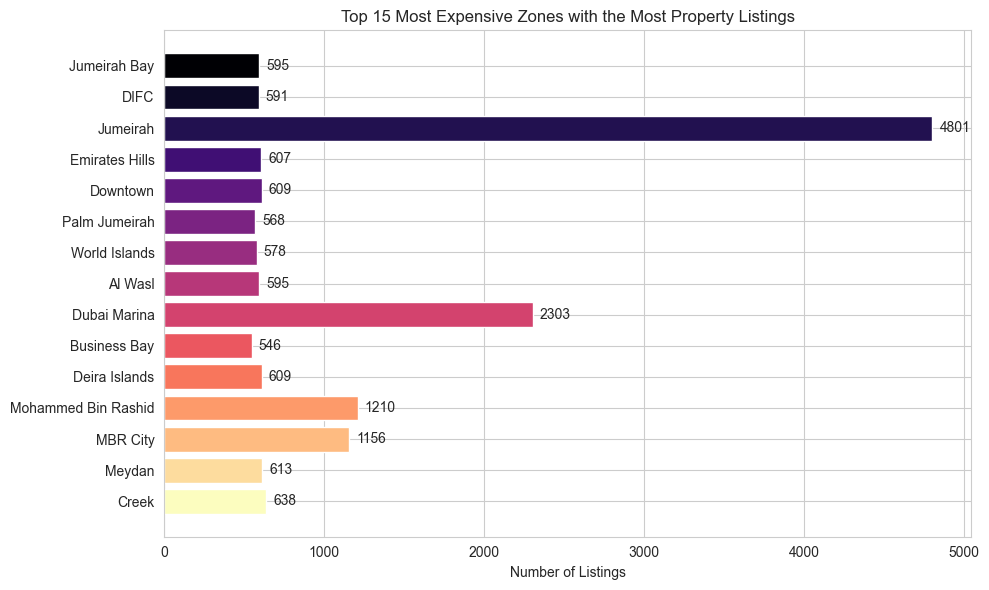

In [56]:
plt.figure(figsize=(10, 6))
barh = plt.barh(y=top15['zone'], width=top15['n_listings'], color=colors)
plt.title('Top 15 Most Expensive Zones with the Most Property Listings')
plt.xlabel('Number of Listings')
plt.bar_label(barh, fmt='%.0f', padding=5)
plt.gca().invert_yaxis()
plt.tight_layout()

file_path = os.path.join('plots', 'top15_zones_n_listings.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.3 What has the biggest influence on property prices?

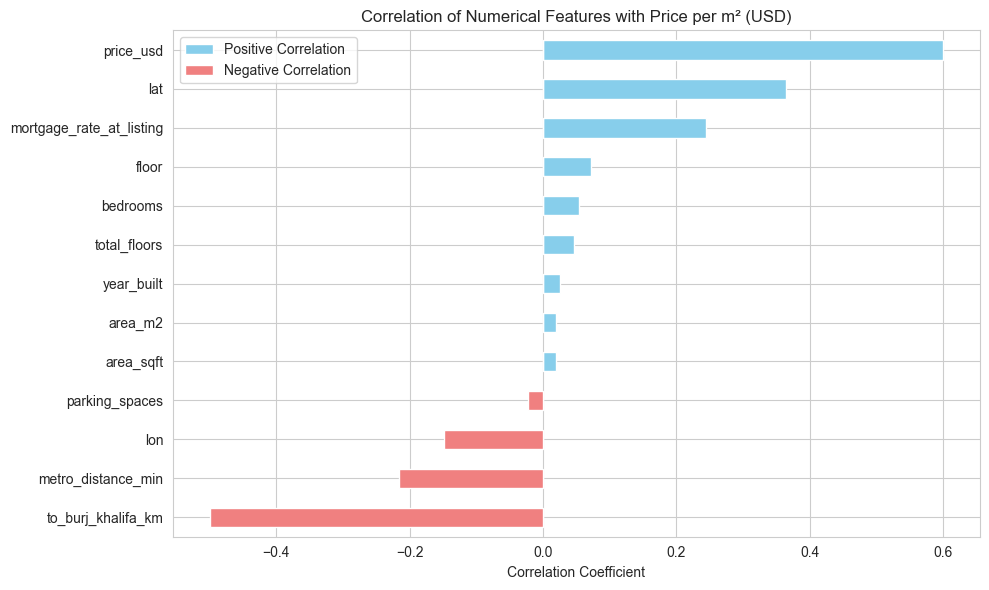

In [57]:
corr_with_price =  secondary.select_dtypes(include=[np.number]).corr()['price_per_m2_usd'].sort_values(ascending=True)

plt.figure(figsize=(10, 6))
corr_with_price.drop(['price_per_m2_usd', 'price_per_sqft_usd']).where(corr_with_price.drop(['price_per_m2_usd', 'price_per_sqft_usd']) >= 0).plot(kind='barh', color='skyblue', label='Positive Correlation')
corr_with_price.drop(['price_per_m2_usd', 'price_per_sqft_usd']).where(corr_with_price.drop(['price_per_m2_usd', 'price_per_sqft_usd']) < 0).plot(kind='barh', color='lightcoral', label='Negative Correlation')
plt.title('Correlation of Numerical Features with Price per m² (USD)')
plt.xlabel('Correlation Coefficient')
plt.legend()
plt.tight_layout()

file_path = os.path.join('plots', 'correlation_with_price_per_m2.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.4 Real estate price mapping in Dubai

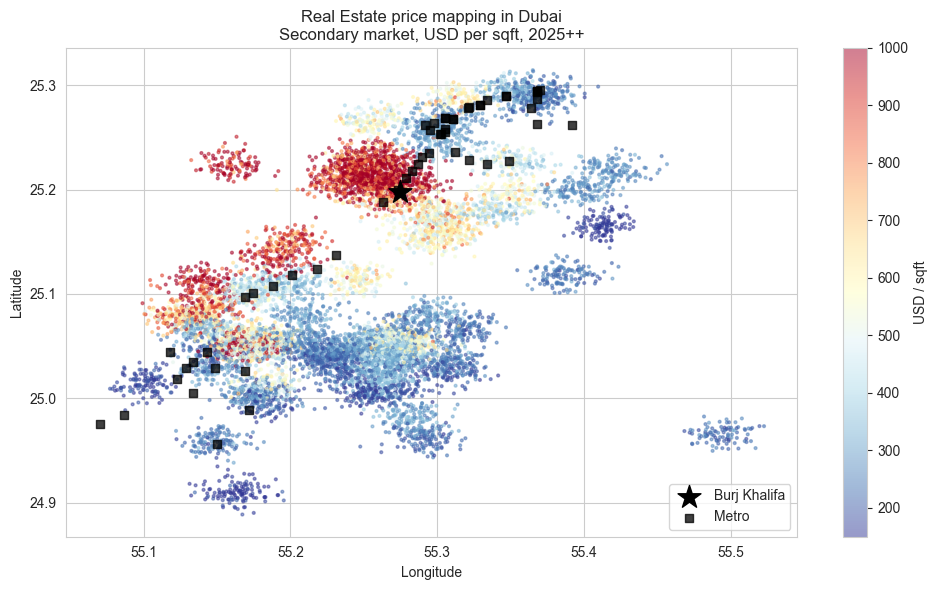

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
recent_full = secondary[secondary['date_listed'] >= '2025-01-01']
n_sample = min(150000, len(recent_full))
recent = recent_full.sample(n=n_sample, random_state=42) if n_sample > 0  else recent_full

sc = ax.scatter(recent['lon'], recent['lat'],
                c = recent['price_per_sqft_usd'], cmap='RdYlBu_r',
                s=4, alpha=0.5, vmin=150, vmax=1000)

# Burj Khalifa
ax.scatter([55.2744], [25.1972], s=300, c='black', marker='*',
           label='Burj Khalifa', zorder=5)
# Metro
ax.scatter(metro_prices['lon'], metro_prices['lat'], s=30, c='black', alpha=0.75, marker='s', label='Metro')

ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Real Estate price mapping in Dubai\nSecondary market, USD per sqft, 2025++')
plt.colorbar(sc, ax=ax, label='USD / sqft')
ax.legend(loc='lower right')
plt.tight_layout()

file_path = os.path.join('plots', 'real_estate_dubai_price_map.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.5 Dubai Real Estate vs CBUAE Rate (2020-2026)

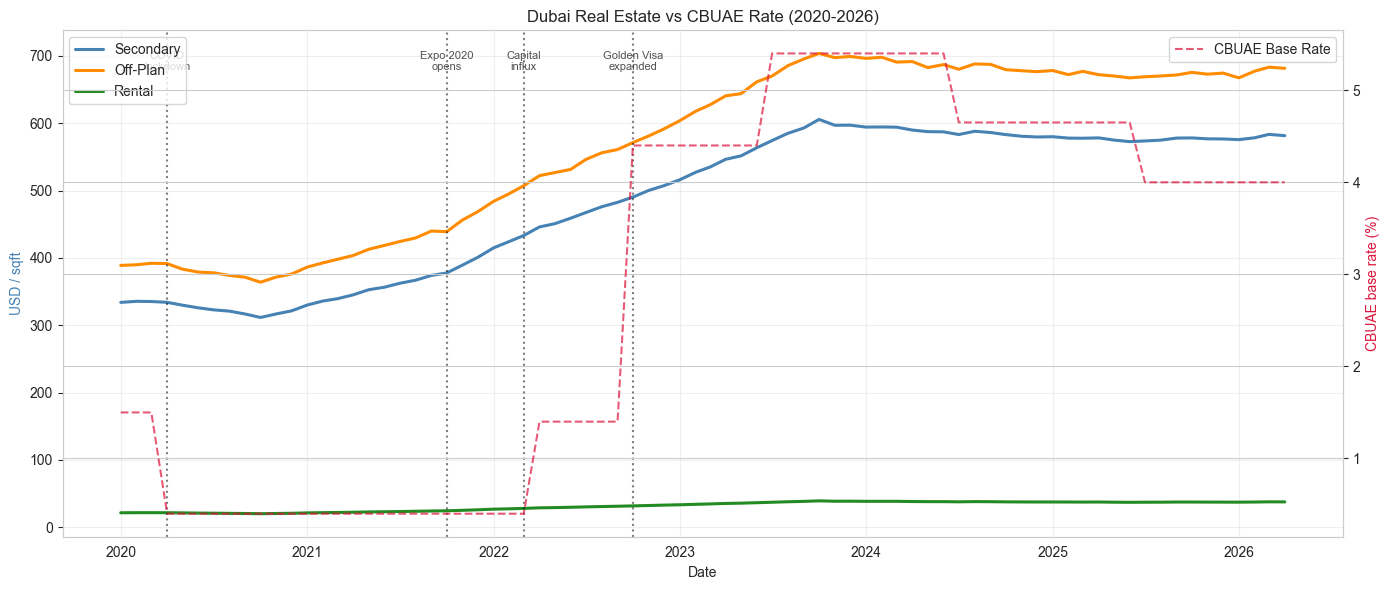

In [59]:
area_prices['date'] = pd.to_datetime(area_prices['year_month'])
city_avg = area_prices.groupby('date').agg(
    secondary=('secondary_price_per_sqft_usd', 'mean'),
    offplan=('offplan_price_per_sqft_usd', 'mean'),
    rental=('rental_price_per_sqft_annual_usd', 'mean'),
    cbuae=('cbuae_base_rate_pct', 'first'),
    mortgage=('avg_mortgage_rate_pct', 'first'),
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(city_avg['date'], city_avg['secondary'], label='Secondary',
         color='steelblue', linewidth=2.2)
ax1.plot(city_avg['date'], city_avg['offplan'], label='Off-Plan',
         color='darkorange', linewidth=2.2)
ax1.plot(city_avg['date'], city_avg['rental'], label='Rental',
         color='forestgreen', linewidth=2.2)

ax1.set_ylabel('USD / sqft', color='steelblue')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(city_avg['date'], city_avg['cbuae'], label='CBUAE Base Rate',
         color='crimson', linewidth=1.5, linestyle='--', alpha=0.7)

ax2.set_ylabel('CBUAE base rate (%)', color='crimson')

# Annotate macro events
events = [
    ('2020-04-01', 'COVID\nlockdown'),
    ('2021-10-01', 'Expo 2020\nopens'),
    ('2022-03-01', 'Capital\ninflux'),
    ('2022-10-01', 'Golden Visa\nexpanded'),
]
for d, label in events:
    ax1.axvline(pd.to_datetime(d), color='black', linestyle=':', alpha=0.5)
    ax1.annotate(label, xy=(pd.to_datetime(d), ax1.get_ylim()[1]*0.92),
                 fontsize=8, ha='center', alpha=0.8)

ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
ax1.set_title('Dubai Real Estate vs CBUAE Rate (2020-2026)')
ax1.grid(alpha=0.3)
plt.tight_layout()

file_path = os.path.join('plots', 'real_estate_vs_cbuae_rate.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.6 How does proximity to key landmarks affect property prices?

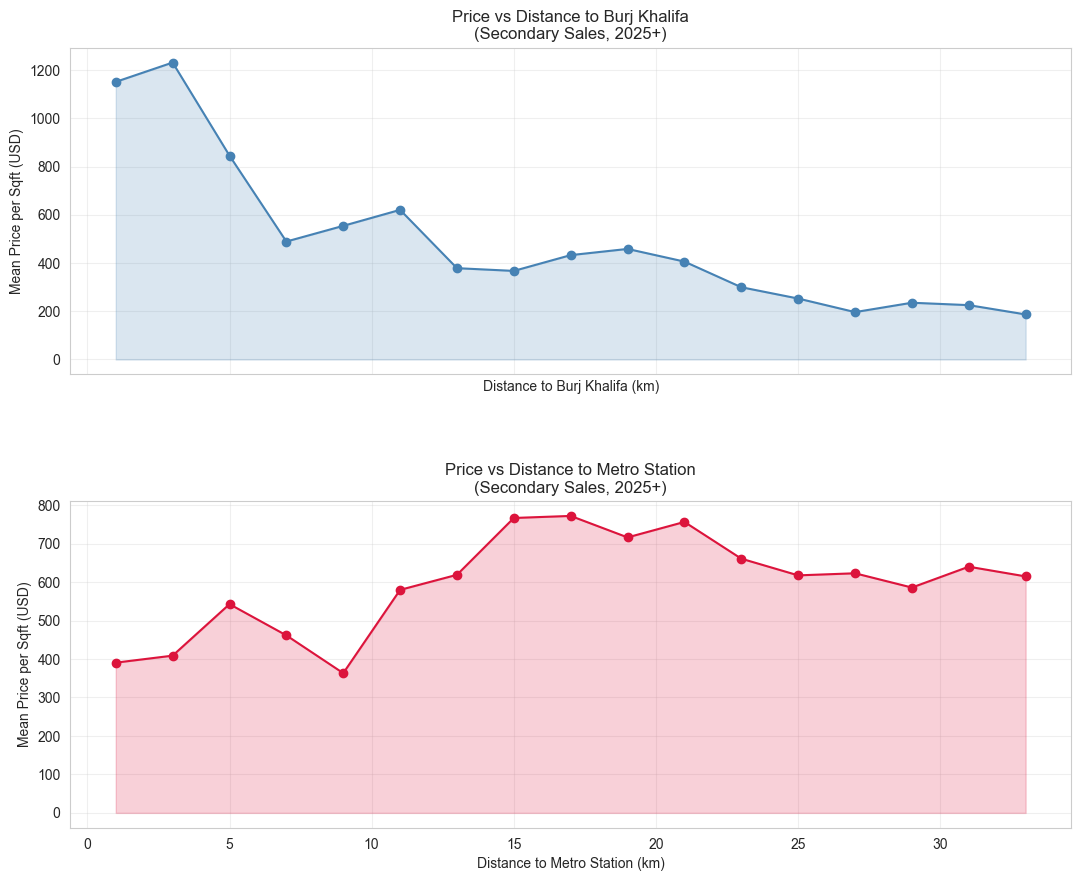

In [60]:
recent_secondary = secondary[secondary['date_listed'] >= '2025-01-01']
bins = np.arange(0, 35, 2)
recent_d = recent.copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

recent_d['dist_bin_burj'] = pd.cut(recent_d['to_burj_khalifa_km'], bins=bins)
recent_d['dist_bin_metro'] = pd.cut(recent_d['metro_distance_min'], bins=bins)
agg_burj = recent_d.groupby('dist_bin_burj')['price_per_sqft_usd'].agg(['mean', 'count']).reset_index()
agg_metro = recent_d.groupby('dist_bin_metro')['price_per_sqft_usd'].agg(['mean', 'count']).reset_index()

agg_burj['dist_mid'] = agg_burj['dist_bin_burj'].apply(lambda x: x.mid)
agg_metro['dist_mid'] = agg_metro['dist_bin_metro'].apply(lambda x: x.mid)
agg_burj = agg_burj[agg_burj['count'] >= 30]
agg_metro = agg_metro[agg_metro['count'] >= 30]

ax1.plot(agg_burj['dist_mid'], agg_burj['mean'], marker='o', color='steelblue')
ax1.fill_between(agg_burj['dist_mid'], agg_burj['mean'], alpha=0.2, color='steelblue')
ax1.set_xlabel('Distance to Burj Khalifa (km)')
ax1.set_ylabel('Mean Price per Sqft (USD)')
ax1.set_title('Price vs Distance to Burj Khalifa\n(Secondary Sales, 2025+)')
ax1.grid(alpha=0.3)

ax2.plot(agg_metro['dist_mid'], agg_metro['mean'], marker='o', color='crimson')
ax2.fill_between(agg_metro['dist_mid'], agg_metro['mean'], alpha=0.2, color='crimson')
ax2.set_xlabel('Distance to Metro Station (km)')
ax2.set_ylabel('Mean Price per Sqft (USD)')
ax2.set_title('Price vs Distance to Metro Station\n(Secondary Sales, 2025+)')
ax2.grid(alpha=0.3)

plt.tight_layout(pad=5)

file_path = os.path.join('plots', 'price_vs_distance_burj_and_metro.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.7 Do freehold areas have higher property prices than non-freehold areas?

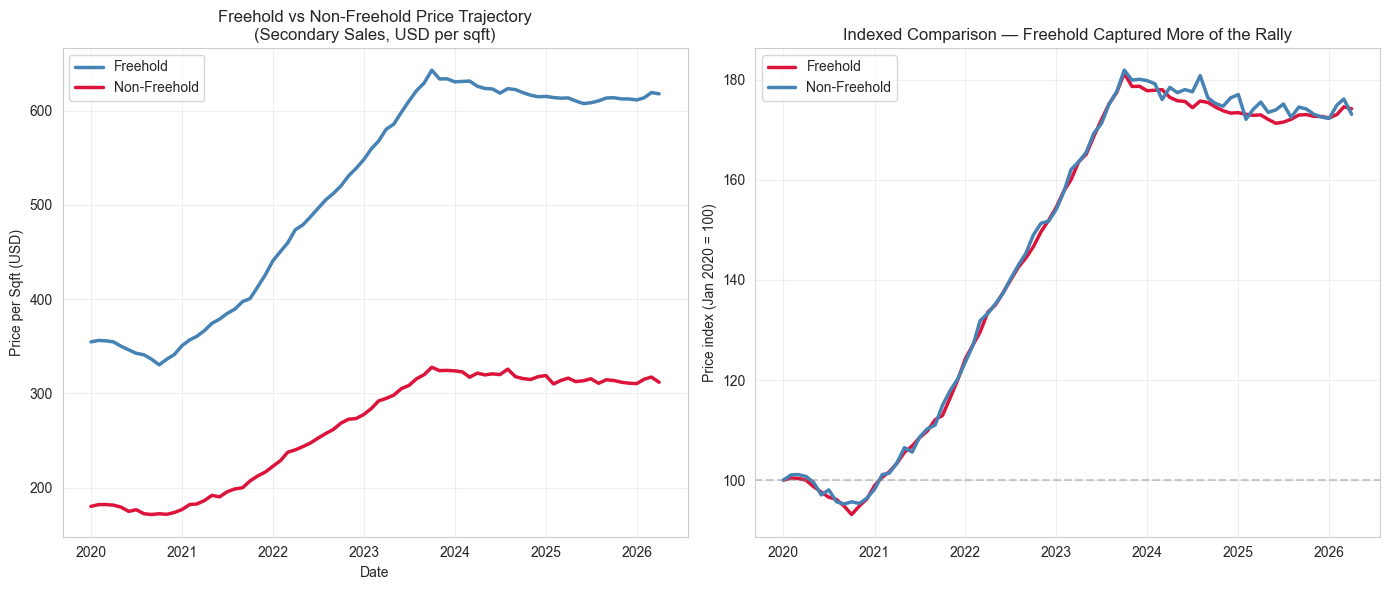

In [61]:
area_prices['date'] = pd.to_datetime(area_prices['year_month'])
freehold = area_prices[area_prices['is_freehold'] == True].groupby('date')['secondary_price_per_sqft_usd'].mean()
non_freehold = area_prices[area_prices['is_freehold'] == False].groupby('date')['secondary_price_per_sqft_usd'].mean()

fig, ax = plt.subplots(1,2,figsize=(14, 6))

ax[0].plot(freehold.index, freehold.values, label='Freehold', color='steelblue', linewidth=2.5)
ax[0].plot(non_freehold.index, non_freehold.values, label='Non-Freehold', color='crimson', linewidth=2.5)
ax[0].set_title('Freehold vs Non-Freehold Price Trajectory\n(Secondary Sales, USD per sqft)')
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Price per Sqft (USD)')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Comparison Index 
freehold_idx = 100 * freehold / freehold.iloc[0]
non_freehold_idx = 100 * non_freehold / non_freehold.iloc[0]
ax[1].plot(freehold_idx.index, freehold_idx.values, label='Freehold',
             color='crimson', linewidth=2.5)
ax[1].plot(non_freehold_idx.index, non_freehold_idx.values, label='Non-Freehold',
             color='steelblue', linewidth=2.5)
ax[1].axhline(100, color='gray', linestyle='--', alpha=0.4)
ax[1].set_ylabel('Price index (Jan 2020 = 100)')
ax[1].set_title('Indexed Comparison — Freehold Captured More of the Rally')
ax[1].legend()
ax[1].grid(alpha=0.3)
plt.tight_layout()

file_path = os.path.join('plots', 'freehold_vs_non_freehold_price_trajectory.png')
plt.savefig(file_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### 1.8 Are short-term rentals more expensive on a per-square-foot basis than yearly rentals?

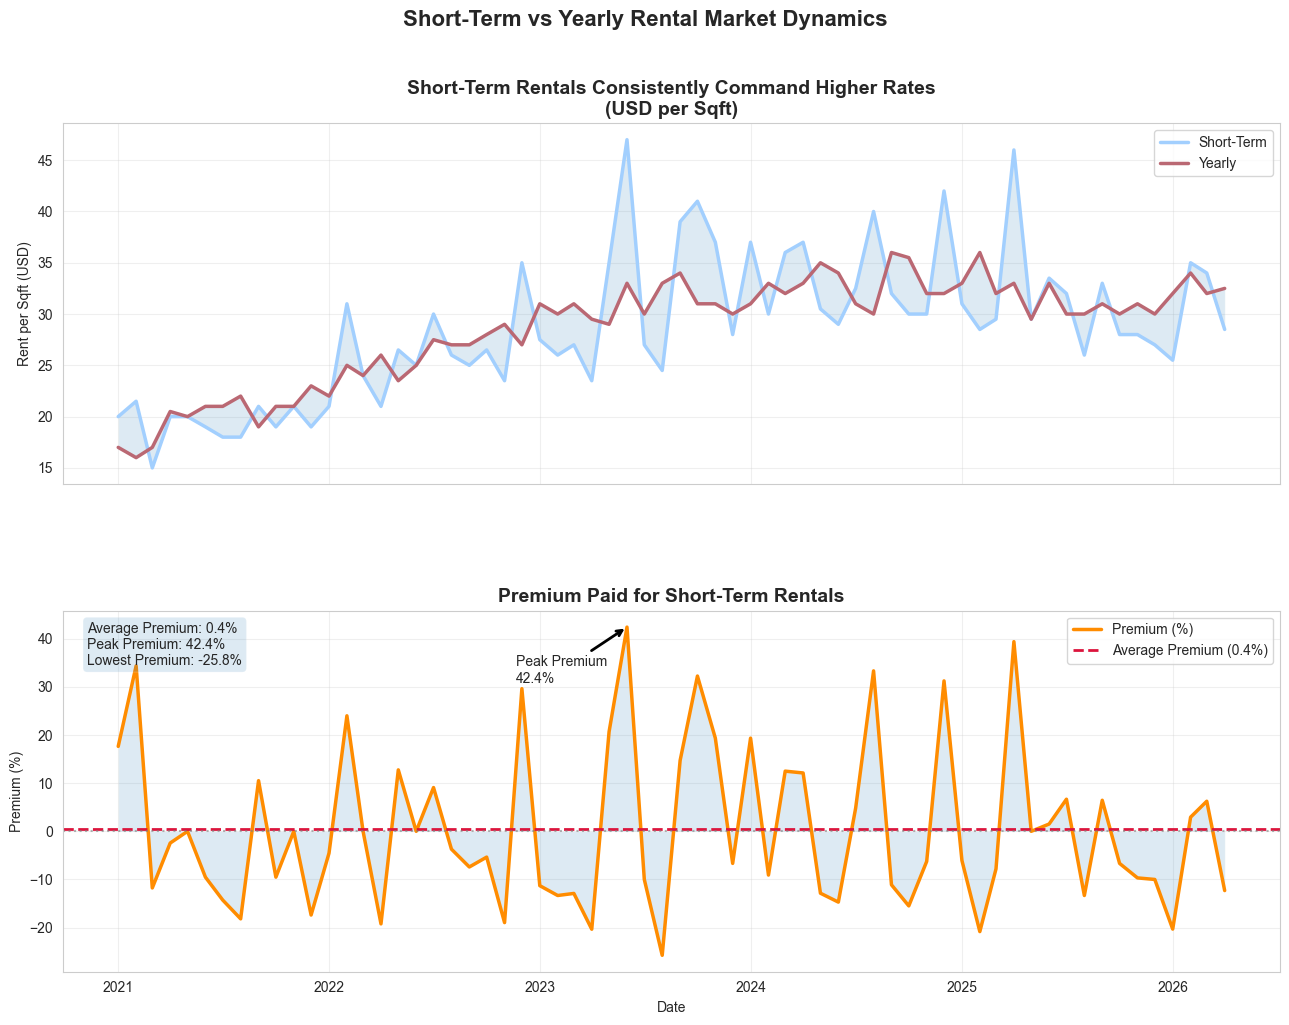

In [69]:
rentals['date'] = pd.to_datetime(rentals['date_listed'])
rentals['month'] = rentals['date'].dt.to_period('M')

rentals_contracts = (
    rentals
    .groupby(['month', 'contract_type'])['rent_per_sqft_usd']
    .median()
    .reset_index()
)

rentals_contracts['month'] = rentals_contracts['month'].dt.to_timestamp()

short_contracts = (
    rentals_contracts[
        rentals_contracts['contract_type'] == 'short_term'
    ][['month', 'rent_per_sqft_usd']]
    .rename(columns={'rent_per_sqft_usd': 'short_term'})
)

yearly_contracts = (
    rentals_contracts[
        rentals_contracts['contract_type'] == 'yearly'
    ][['month', 'rent_per_sqft_usd']]
    .rename(columns={'rent_per_sqft_usd': 'yearly'})
)

comparison = short_contracts.merge(
    yearly_contracts,on='month',how='inner'
)

comparison['premium_pct'] = (
    (comparison['short_term'] - comparison['yearly'])
    / comparison['yearly']
) * 100

# Summary Metrics

avg_premium = comparison['premium_pct'].mean()
max_premium = comparison['premium_pct'].max()
min_premium = comparison['premium_pct'].min()

peak_idx = comparison['premium_pct'].idxmax()

fig, ax = plt.subplots(
    2,
    1,
    figsize=(13, 10),
    sharex=True
)

# Plot 1 Short vs Yearly

ax[0].plot( comparison['month'], comparison['short_term'], label='Short-Term', color='xkcd:baby blue', linewidth=2.5)

ax[0].plot( comparison['month'], comparison['yearly'], label='Yearly', color='xkcd:dusky rose', linewidth=2.5)

ax[0].fill_between( comparison['month'], comparison['short_term'], comparison['yearly'], alpha=0.15)

ax[0].set_title('Short-Term Rentals Consistently Command Higher Rates\n(USD per Sqft)', fontsize=14,weight='bold')
ax[0].set_ylabel('Rent per Sqft (USD)')
ax[0].legend()
ax[0].grid(alpha=0.3)

# Plot 2 Premium Analysis

ax[1].plot(comparison['month'], comparison['premium_pct'], color='darkorange', linewidth=2.5, label='Premium (%)')

ax[1].fill_between(comparison['month'], comparison['premium_pct'], 0, alpha=0.15)

ax[1].axhline(avg_premium, linestyle='--', linewidth=2, color='crimson',
    label=f'Average Premium ({avg_premium:.1f}%)'
)

ax[1].axhline(0,linestyle=':',color='gray',alpha=0.6)

# Peak Annotation

ax[1].annotate(
    f'Peak Premium\n{max_premium:.1f}%',
    xy=(
        comparison.loc[peak_idx, 'month'],
        comparison.loc[peak_idx, 'premium_pct']
    ),
    xytext=(-80, -40),  # geser ke kiri
    textcoords='offset points',
    arrowprops=dict(
        arrowstyle='->',
        color='black',
        lw=2
    ),
    fontsize=10
)

ax[1].set_title('Premium Paid for Short-Term Rentals',fontsize=14,weight='bold')

ax[1].set_xlabel('Date')
ax[1].set_ylabel('Premium (%)')
ax[1].legend()
ax[1].grid(alpha=0.3)

# Text Summary Box

summary = (
    f'Average Premium: {avg_premium:.1f}%\n'
    f'Peak Premium: {max_premium:.1f}%\n'
    f'Lowest Premium: {min_premium:.1f}%'
)

ax[1].text(0.02,0.97,
    summary,transform=ax[1].transAxes,va='top',
    bbox=dict(
        boxstyle='round',
        alpha=0.15
    )
)

plt.suptitle('Short-Term vs Yearly Rental Market Dynamics',fontsize=16,weight='bold', y=1.02)

plt.tight_layout()
fig.subplots_adjust(hspace=0.35)

file_path = os.path.join('plots','short_term_vs_yearly_rental_premium.png')

plt.savefig(file_path,dpi=300,bbox_inches='tight',facecolor='white')

plt.show()